# Portfolio Optimization

In the previous notebook, Monte Carlo simulation was used to approximate the minimum-volatility and maximum-Sharpe portfolios.

In this notebook, I use numerical optimization to find these portfolios directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

In [2]:
tickers = [
    "AAPL",
    "MSFT",
    "JPM",
    "JNJ",
    "XOM",
    "PG",
    "CAT",
    "NEE"
]

start_date = "2016-01-01"
end_date = "2026-01-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = data["Close"]
returns = prices.pct_change().dropna()

mu = returns.mean() * 252
cov_matrix = returns.cov() * 252

n_assets = len(tickers)
risk_free_rate = 0.0

In [3]:
weights = np.random.random(n_assets)
weights = weights / weights.sum()

## 1. Minimum-Variance Portfolio

The minimum-variance portfolio is the portfolio with the lowest possible
variance subject to the portfolio constraints.

I assume a long-only portfolio, so each weight must lie between 0 and 1,
and all portfolio weights must sum to one.

In [4]:
def portfolio_variance(weights):
    return weights @ cov_matrix @ weights

In [ ]:
test_weights = np.ones(n_assets) / n_assets
portfolio_variance(test_weights)

np.float64(0.02947033442801482)

## 2. Optimization Constraints

The portfolio weights must sum to one. I also restrict each weight to be between 0 and 1, which means that short selling is not allowed.

The long-only constraint is used to keep the optimization consistent with the Monte Carlo simulation, where all randomly generated portfolio weights were non-negative.

In [6]:
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

bounds = [(0, 1)] * n_assets

initial_weights = np.ones(n_assets) / n_assets

## 3. Minimum-Variance Optimization

Using the constraints above, I use `scipy.optimize.minimize` to find the portfolio weights that minimize portfolio variance.

In [7]:
min_var_result = minimize(
    portfolio_variance,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

min_var_weights = min_var_result.x
min_var_return = min_var_weights @ mu
min_var_variance = portfolio_variance(min_var_weights)
min_var_volatility = np.sqrt(min_var_variance)

print("Optimization successful:", min_var_result.success)
print(f"Expected annual return: {min_var_return:.2%}")
print(f"Annual volatility: {min_var_volatility:.2%}")
print(f"Sum of weights: {min_var_weights.sum():.4f}")

Optimization successful: True
Expected annual return: 14.04%
Annual volatility: 15.14%
Sum of weights: 1.0000


In [8]:
min_var_allocation = pd.Series(
    min_var_weights,
    index=tickers,
    name="Weight"
)

min_var_allocation

AAPL    0.011984
MSFT    0.038682
JPM     0.354804
JNJ     0.017155
XOM     0.076181
PG      0.074523
CAT     0.320430
NEE     0.106242
Name: Weight, dtype: float64

## 4. Maximum-Sharpe Portfolio

The maximum-Sharpe portfolio aims to maximize the expected excess return per unit of risk.

Since `scipy.optimize.minimize` performs minimization, I minimize the negative Sharpe ratio, which is equivalent to maximizing the Sharpe ratio.

For consistency with the previous analysis, I continue to assume a risk-free rate of 0 and use the same long-only constraints.

In [9]:
def negative_sharpe(weights):
    portfolio_return = weights @ mu
    portfolio_volatility = np.sqrt(weights @ cov_matrix @ weights)
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    return -sharpe_ratio


max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = max_sharpe_result.x

max_sharpe_return = max_sharpe_weights @ mu
max_sharpe_variance = portfolio_variance(max_sharpe_weights)
max_sharpe_volatility = np.sqrt(max_sharpe_variance)
max_sharpe_ratio = (
    (max_sharpe_return - risk_free_rate)
    / max_sharpe_volatility
)

print("Optimization successful:", max_sharpe_result.success)
print(f"Expected annual return: {max_sharpe_return:.2%}")
print(f"Annual volatility: {max_sharpe_volatility:.2%}")
print(f"Sharpe ratio: {max_sharpe_ratio:.2f}")
print(f"Sum of weights: {max_sharpe_weights.sum():.4f}")

Optimization successful: True
Expected annual return: 24.17%
Annual volatility: 19.38%
Sharpe ratio: 1.25
Sum of weights: 1.0000


In [10]:
max_sharpe_allocation = pd.Series(
    max_sharpe_weights,
    index=tickers,
    name="Weight"
)

max_sharpe_allocation

AAPL    2.015412e-01
MSFT    2.541875e-01
JPM     1.073065e-01
JNJ     5.009736e-02
XOM     2.226638e-01
PG      1.642037e-01
CAT     5.281453e-18
NEE     7.814573e-18
Name: Weight, dtype: float64

## 5. Portfolio Comparison

I compare the equal-weight benchmark with the two optimized portfolios.

The minimum-variance portfolio focuses only on reducing risk, while the maximum-Sharpe portfolio balances expected return and volatility.

In [11]:
equal_weights = np.ones(n_assets) / n_assets

equal_return = equal_weights @ mu
equal_variance = portfolio_variance(equal_weights)
equal_volatility = np.sqrt(equal_variance)
equal_sharpe = (
    (equal_return - risk_free_rate)
    / equal_volatility
)

comparison = pd.DataFrame({
    "Expected Return": [
        equal_return,
        min_var_return,
        max_sharpe_return
    ],
    "Volatility": [
        equal_volatility,
        min_var_volatility,
        max_sharpe_volatility
    ],
    "Sharpe Ratio": [
        equal_sharpe,
        (min_var_return - risk_free_rate) / min_var_volatility,
        max_sharpe_ratio
    ]
}, index=[
    "Equal Weight",
    "Minimum Variance",
    "Maximum Sharpe"
])

comparison

,Expected Return,Volatility,Sharpe Ratio
Equal Weight,0.198329,0.171669,1.155300
Minimum Variance,0.140365,0.151382,0.927225
Maximum Sharpe,0.241706,0.193845,1.246905


## 6. Portfolio Allocations

The optimized portfolios can have very different asset allocations because they optimize different objectives.

In [12]:
allocations = pd.DataFrame({
    "Equal Weight": equal_weights,
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights
}, index=tickers)

allocations

,Equal Weight,Minimum Variance,Maximum Sharpe
AAPL,0.125,0.011984,2.015412e-01
MSFT,0.125,0.038682,2.541875e-01
JPM,0.125,0.354804,1.073065e-01
JNJ,0.125,0.017155,5.009736e-02
XOM,0.125,0.076181,2.226638e-01
PG,0.125,0.074523,1.642037e-01
CAT,0.125,0.320430,5.281453e-18
NEE,0.125,0.106242,7.814573e-18


## 7. Risk-Return Comparison

The optimized portfolios can also be compared visually in risk-return space.

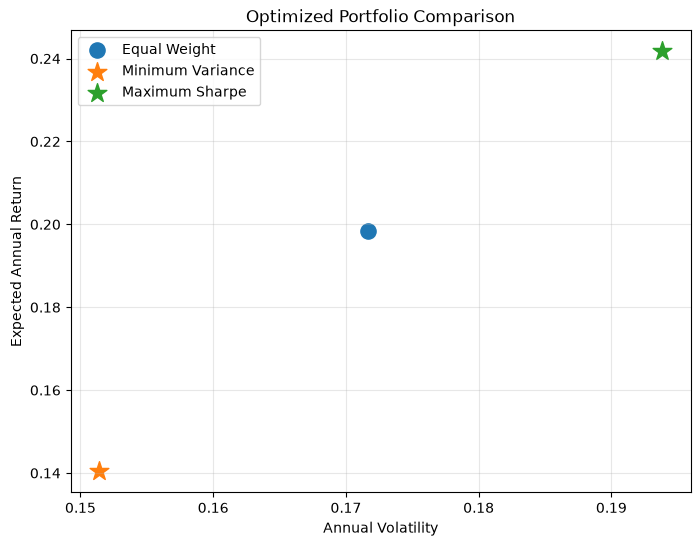

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    equal_volatility,
    equal_return,
    marker="o",
    s=120,
    label="Equal Weight"
)

plt.scatter(
    min_var_volatility,
    min_var_return,
    marker="*",
    s=200,
    label="Minimum Variance"
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=200,
    label="Maximum Sharpe"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Optimized Portfolio Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8. Conclusion

Numerical optimization improves on the random search used in the Monte Carlo simulation by directly searching for portfolio weights that satisfy a specific objective.

The minimum-variance portfolio achieves the lowest volatility among the feasible long-only portfolios, while the maximum-Sharpe portfolio targets the highest expected excess return per unit of risk.

These results are based on historical estimates of expected returns and covariances. Therefore, the optimized weights should not be interpreted as portfolios that will necessarily perform best in the future. Their out-of-sample performance will be evaluated later through backtesting.